In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Conv2D,

    MaxPooling2D,

    Flatten,

    Dense,

    Dropout

)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (

    confusion_matrix,

    classification_report

)

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
print(X_train.shape)

print(y_train.shape)

print(X_test.shape)

print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
class_names = [

    "T-shirt/top",

    "Trouser",

    "Pullover",

    "Dress",

    "Coat",

    "Sandal",

    "Shirt",

    "Sneaker",

    "Bag",

    "Ankle boot"

]

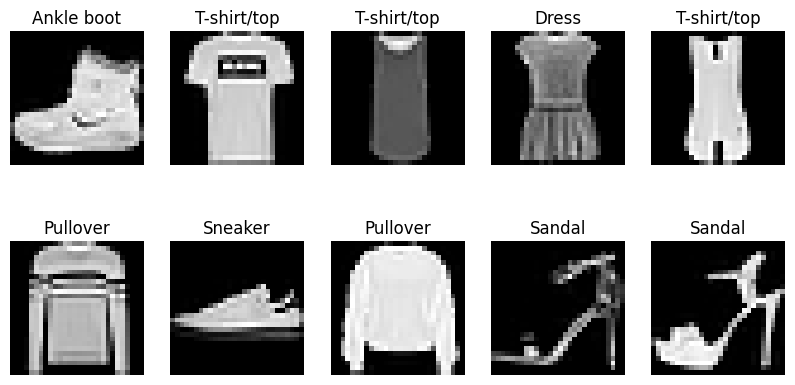

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(

        X_train[i],

        cmap='gray'

    )

    plt.title(

        class_names[

            y_train[i]

        ]

    )

    plt.axis('off')

plt.show()

In [6]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [7]:
X_train = X_train.reshape(

    -1,

    28,

    28,

    1

)

X_test = X_test.reshape(

    -1,

    28,

    28,

    1

)

In [8]:
X_train.shape

(60000, 28, 28, 1)

In [9]:
y_train = to_categorical(

    y_train,

    10

)

y_test = to_categorical(

    y_test,

    10

)

In [10]:
cnn = Sequential()

In [11]:
cnn.add(

    Conv2D(

        filters=32,

        kernel_size=(3,3),

        activation='relu',

        input_shape=(28,28,1)

    )

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn.add(

    MaxPooling2D(

        pool_size=(2,2)

    )

)

In [13]:
cnn.add(

    Conv2D(

        filters=64,

        kernel_size=(3,3),

        activation='relu'

    )

)

In [14]:
cnn.add(

    MaxPooling2D(

        pool_size=(2,2)

    )

)

In [15]:
cnn.add(

    Flatten()

)

In [16]:
cnn.add(

    Dense(

        units=128,

        activation='relu'

    )

)

In [17]:
cnn.add(

    Dropout(

        0.5

    )

)

In [18]:
cnn.add(

    Dense(

        units=10,

        activation='softmax'

    )

)

In [19]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
cnn.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [21]:
history = cnn.fit(

    X_train,

    y_train,

    epochs=10,

    batch_size=32,

    validation_split=0.2

)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7846 - loss: 0.5949 - val_accuracy: 0.8551 - val_loss: 0.3848
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8575 - loss: 0.3996 - val_accuracy: 0.8808 - val_loss: 0.3189
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8756 - loss: 0.3448 - val_accuracy: 0.8859 - val_loss: 0.3014
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8872 - loss: 0.3112 - val_accuracy: 0.8972 - val_loss: 0.2757
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8933 - loss: 0.2922 - val_accuracy: 0.8978 - val_loss: 0.2805
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9014 - loss: 0.2703 - val_accuracy: 0.9040 - val_loss: 0.2582
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9069 - loss: 0.2534 - val_accuracy: 0.9009 - val_loss: 0.2615
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9120 - loss: 0.2388 

In [22]:
cnn.evaluate(

    X_test,

    y_test

)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9078 - loss: 0.2603


[0.2603400945663452, 0.907800018787384]

In [23]:
y_pred = cnn.predict(

    X_test

)

y_pred = np.argmax(

    y_pred,

    axis=1

)

y_true = np.argmax(

    y_test,

    axis=1

)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [24]:
print(

    confusion_matrix(

        y_true,

        y_pred

    )

)

[[874   0  19  20   2   1  79   0   5   0]
 [  2 973   0  17   2   0   4   0   2   0]
 [ 14   0 870   7  38   0  69   0   2   0]
 [ 13   1  13 910  21   0  39   0   2   1]
 [  2   0  61  26 845   0  63   0   2   1]
 [  0   0   0   0   0 970   0  17   1  12]
 [126   0  66  20  57   0 717   0  14   0]
 [  0   0   0   0   0   4   0 969   0  27]
 [  1   1   4   2   2   2   4   3 981   0]
 [  0   0   0   0   0   6   0  25   0 969]]


In [25]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )

)

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.84      0.87      0.86      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.87      0.84      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.74      0.72      0.73      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [26]:
cnn.save(

    "fashion_mnist_cnn.keras"

)

In [27]:
from google.colab import files

files.download("fashion_mnist_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>